## Estimating Heat-Related Mortality from Excess Heat Factor (EHF)

After computing the **Excess Heat Factor (EHF)**, the next step is to translate heat exposure into potential health impacts. This is done using an epidemiological exposure–response framework that links heat stress to mortality risk.

The following steps will be carried out:

1. Compute the **Relative Risk (RR)** associated with excess heat exposure.
2. Compute the **Attributable Fraction (AF)** of mortality due to heat.
3. Estimate the **number of heat-related deaths**.

---

### 1. Relative Risk (RR)

The relationship between heat exposure and mortality is modeled using a **log-linear risk function**:

$$
RR = \exp(\beta \times \Delta EHF)
$$

where:

- $RR$ = Relative risk of mortality associated with heat exposure  
- $\beta$ = Heat–mortality coefficient (increase in mortality risk per unit increase in heat exposure)  
- $\Delta EHF$ = Change in Excess Heat Factor  

Since EHF already represents **excess heat conditions**, the change in exposure is defined as:

$$
\Delta EHF =
\begin{cases}
EHF, & \text{if } EHF > 0 \\
0, & \text{if } EHF \leq 0
\end{cases}
$$

This ensures that mortality risk is only calculated during **heatwave conditions**.

---

### 2. Attributable Fraction (AF)

The **Attributable Fraction (AF)** represents the proportion of deaths that can be attributed to heat exposure.

It is calculated as:

$$
AF = \frac{RR - 1}{RR}
$$

where:

- $AF$ = Attributable fraction of deaths due to heat
- $RR$ = Relative risk calculated in the previous step

Values of $AF$ range between **0 and 1**, representing the fraction of total mortality attributable to heat stress.

---

### 3. Heat-Related Mortality

The number of heat-related deaths is estimated by applying the attributable fraction to baseline mortality:

$$
H = AF \times M
$$

where:

- $H$ = Heat-attributable deaths  
- $AF$ = Attributable fraction  
- $M$ = Baseline mortality  

This provides an estimate of the number of deaths associated with **excess heat exposure**.

---

### 4. Spatial and Temporal Aggregation

Because the EHF dataset is spatially gridded:

- Relative risk and attributable fractions will first be computed **for each grid cell**.
- These values will then be **aggregated spatially** to obtain national-level estimates.

Daily values will also be **aggregated to yearly totals** to analyze long-term trends in heat exposure and heat-related mortality.

---

The next cells will implement these calculations using the computed **EHF dataset**.at-related mortality over the study period (1991–2024).

## Estimating Heat-Related Mortality from Excess Heat Factor (EHF)

After computing the **Excess Heat Factor (EHF)**, the next step is to translate heat exposure into potential health impacts. This is done using an epidemiological exposure–response framework that links heat stress to mortality risk.

The following steps will be carried out:

1. Compute the **Relative Risk (RR)** associated with excess heat exposure.
2. Compute the **Attributable Fraction (AF)** of mortality due to heat.
3. Estimate the **number of heat-related deaths**.

---

### 1. Relative Risk (RR)

The relationship between heat exposure and mortality is modeled using a **log-linear risk function**:

$$
RR = \exp(\beta \times \Delta EHF)
$$

where:

- $RR$ = Relative risk of mortality associated with heat exposure  
- $\beta$ = Heat–mortality coefficient (increase in mortality risk per unit increase in heat exposure)  
- $\Delta EHF$ = Change in Excess Heat Factor  

Since EHF already represents **excess heat conditions**, the change in exposure is defined as:

$$
\Delta EHF =
\begin{cases}
EHF, & \text{if } EHF > 0 \\
0, & \text{if } EHF \leq 0
\end{cases}
$$

This ensures that mortality risk is only calculated during **heatwave conditions**.

---

### 2. Attributable Fraction (AF)

The **Attributable Fraction (AF)** represents the proportion of deaths that can be attributed to heat exposure.

It is calculated as:

$$
AF = \frac{RR - 1}{RR}
$$

where:

- $AF$ = Attributable fraction of deaths due to heat
- $RR$ = Relative risk calculated in the previous step

Values of $AF$ range between **0 and 1**, representing the fraction of total mortality attributable to heat stress.

---

### 3. Heat-Related Mortality

The number of heat-related deaths is estimated by applying the attributable fraction to baseline mortality:

$$
H = AF \times M
$$

where:

- $H$ = Heat-attributable deaths  
- $AF$ = Attributable fraction  
- $M$ = Baseline mortality  

This provides an estimate of the number of deaths associated with **excess heat exposure**.

---

### 4. Spatial and Temporal Aggregation

Because the EHF dataset is spatially gridded:

- Relative risk and attributable fractions will first be computed **for each grid cell**.
- These values will then be **aggregated spatially** to obtain national-level estimates.

Daily values will also be **aggregated to yearly totals** to analyze long-term trends in heat exposure and heat-related mortality.

---



In [31]:
import xarray as xr
import numpy as np

# Load datasets
Tmax = xr.open_dataset("Ghana_ERA5_d2m_Tx_1991-2024.nc")
Tmin = xr.open_dataset("Ghana_ERA5_d2m_Tn_1991-2024.nc")

# Mean temperature
Tmean = (Tmax["t2m"] + Tmin["t2m"]) / 2
Tmean.name = "Tmean"

# Rolling means
Tmean3 = Tmean.rolling(valid_time=3, min_periods=3).mean()
T30    = Tmean.rolling(valid_time=30, min_periods=30).mean()

# Add day-of-year coordinate
Tmean = Tmean.assign_coords(dayofyear=Tmean["valid_time"].dt.dayofyear)

# 90th percentile climatology
T90_doy = Tmean.groupby("dayofyear").quantile(0.90, dim="valid_time")

# Map percentile back to daily timeline
T90_for_day = T90_doy.sel(dayofyear=Tmean["valid_time"].dt.dayofyear)

# EHI components
EHI_sig  = Tmean3 - T90_for_day
EHI_accl = Tmean3 - T30

sig = xr.where(EHI_sig > 0, EHI_sig, 0)
multiplier = xr.where(EHI_accl > 1, EHI_accl, 1)

# Excess Heat Factor
EHF = sig * multiplier
EHF.name = "EHF"

In [32]:
EHF

<xarray.DataArray 'EHF' (valid_time: 12419, latitude: 31, longitude: 21)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.3337822 , 0.26602364, 0.28180199, ..., 0.4123806 ,
         0.33031807, 0.27798119],
        [0.21111374, 0.16121483, 0.06012154, ..., 0.3679985 ,
         0.37374458, 0.34493599],
        [0.20429001, 0.16051559, 0.02122459, ..., 0.34544868,
         0.37375145, 0.35627632]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.33955956, 0.25909081, 0.28969917, ..., 0.37901268,
         0.35083199, 0.27196579],
        [0.53328514, 0.45888863, 0.4398735 , ..., 0.42160835,
         0.42139549, 0.36192284],
        [0.52207222, 0.49808006, 0.45372505, ..., 0.43294334,
         0.42519722, 0.37237206]]])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1991-01-01T11:30:00 ... 2024-12-3...
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
    dayofyear   (valid_time) int64 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366

In [5]:
EHF_year = EHF.groupby("valid_time.year").sum("valid_time")
print(EHF_year)

<xarray.DataArray 'EHF' (year: 34, latitude: 31, longitude: 21)>
array([[[1.64557610e+00, 1.16029209e+00, 1.92236228e+00, ...,
         5.11625563e+00, 3.09902235e+00, 6.10271478e-01],
        [4.09527668e-01, 1.04343460e+00, 1.74074347e+00, ...,
         3.15510464e+00, 2.03278174e+00, 4.90861530e-01],
        [2.92817868e-01, 3.53628202e-01, 1.10467885e+00, ...,
         1.99001530e+00, 1.83135174e+00, 1.75088272e+00],
        ...,
        [1.96224213e+00, 1.12215958e+00, 1.22663956e+00, ...,
         6.71207886e+00, 6.28933716e+00, 6.51398225e+00],
        [3.68713837e+00, 3.20310898e+00, 3.32200699e+00, ...,
         8.12915726e+00, 8.28607520e+00, 7.74342767e+00],
        [2.82343979e+00, 2.82550316e+00, 3.34755554e+00, ...,
         9.75152940e+00, 9.14925938e+00, 8.49726095e+00]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         2.52922113e+00, 4.33076403e+00, 3.55019755e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         4.5742494

In [6]:
EHF_year = EHF_year.squeeze(drop=True)

In [7]:
EHF_ghana = EHF_year.mean(dim=["latitude","longitude"])

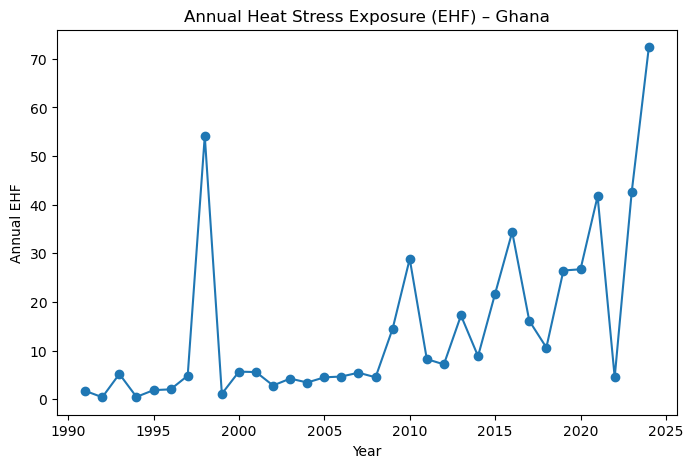

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

EHF_ghana.plot(marker='o')

plt.title("Annual Heat Stress Exposure (EHF) – Ghana")
plt.ylabel("Annual EHF")
plt.xlabel("Year")

plt.show()

In [9]:
import numpy as np

years = EHF_ghana.year.values
values = EHF_ghana.values

coef = np.polyfit(years, values, 1)

trend_per_year = coef[0]
trend_per_decade = trend_per_year * 10

print("Trend:", trend_per_decade, "EHF units per decade")

Trend: 9.988301848580134 EHF units per decade


In [10]:
heatwave_days = (EHF > 0).groupby("valid_time.year").sum("valid_time")

heatwave_days_ghana = heatwave_days.mean(dim=["latitude","longitude"])

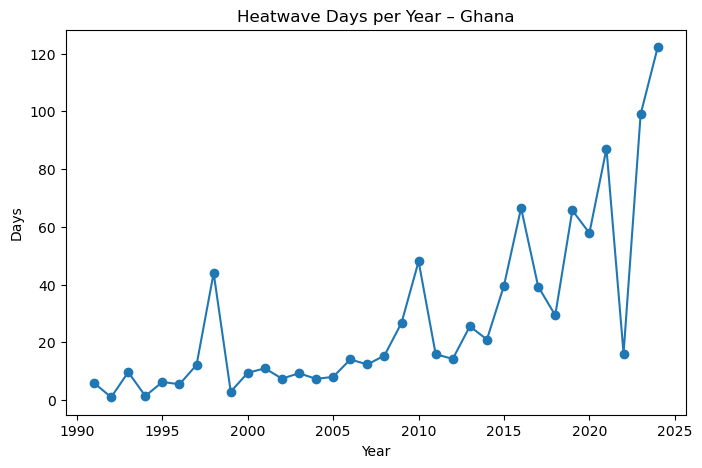

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

heatwave_days_ghana.plot(marker='o')

plt.title("Heatwave Days per Year – Ghana")
plt.ylabel("Days")
plt.xlabel("Year")

plt.show()

In [12]:
EHF_max = EHF.groupby("valid_time.year").max()

EHF_max_ghana = EHF_max.mean(dim=["latitude","longitude"])

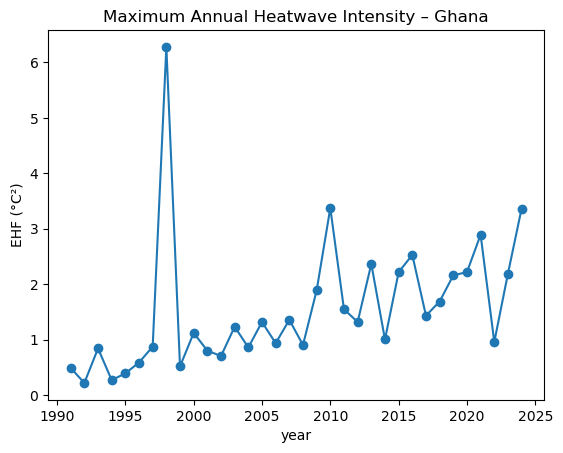

In [13]:
EHF_max_ghana.plot(marker='o')

plt.title("Maximum Annual Heatwave Intensity – Ghana")
plt.ylabel("EHF (°C²)")
plt.show()

In [15]:
import numpy as np

beta = 0.04

RR = np.exp(beta * EHF_ghana)
RR

<xarray.DataArray 'EHF' (year: 34)>
array([ 1.07157635,  1.01709737,  1.23163041,  1.01979182,  1.07813425,
        1.08518496,  1.21384618,  8.72158084,  1.04569783,  1.25520692,
        1.25100731,  1.119873  ,  1.18557821,  1.14793939,  1.1978353 ,
        1.20585714,  1.24438212,  1.19817614,  1.78738186,  3.17318087,
        1.39149661,  1.33263119,  1.99242996,  1.42508264,  2.38474626,
        3.95687769,  1.90697304,  1.5302617 ,  2.88409367,  2.91329482,
        5.31349519,  1.19805847,  5.52221497, 18.09498269])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

In [17]:
AF = (RR - 1) / RR
AF

<xarray.DataArray 'EHF' (year: 34)>
array([0.06679538, 0.01680997, 0.18806812, 0.0194077 , 0.07247173,
       0.0784981 , 0.17617239, 0.88534189, 0.0437008 , 0.20331861,
       0.20064416, 0.1070416 , 0.1565297 , 0.12887387, 0.16516069,
       0.17071437, 0.19638833, 0.16539817, 0.44052246, 0.68485881,
       0.28134931, 0.24960483, 0.4981003 , 0.29828631, 0.58066817,
       0.74727548, 0.47560874, 0.346517  , 0.65327062, 0.65674603,
       0.81179996, 0.1653162 , 0.81891324, 0.94473606])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

In [20]:
baseline_deaths = 140000

heat_deaths = AF * baseline_deaths
heat_deaths

<xarray.DataArray 'EHF' (year: 34)>
array([  9351.35274283,   2353.39554332,  26329.53655452,   2717.07822125,
        10146.04196827,  10989.733946  ,  24664.13454823, 123947.86419956,
         6118.11139996,  28464.60500571,  28090.18213374,  14985.8241171 ,
        21914.15863492,  18042.34114333,  23122.49606742,  23900.01156575,
        27494.36555176,  23155.74323891,  61673.14500349,  95880.23319829,
        39388.90360748,  34944.67668968,  69734.0420822 ,  41760.08316755,
        81293.54447983, 104618.56770151,  66585.22329676,  48512.3803494 ,
        91457.88731797,  91944.44481817, 113651.99460915,  23144.26786379,
       114647.85403686, 132263.04868948])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

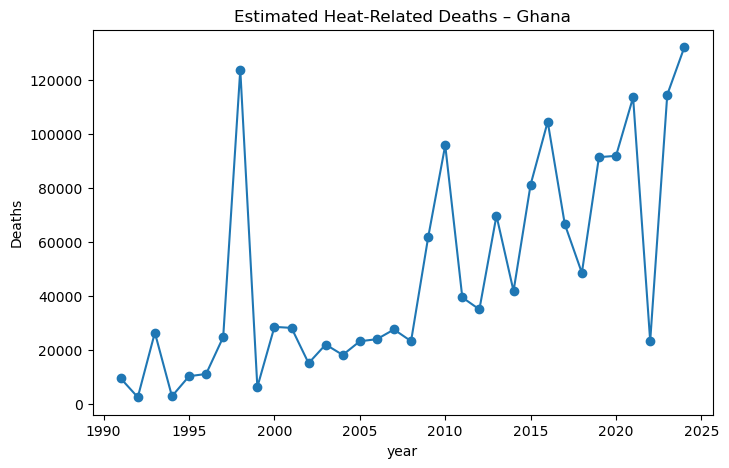

In [19]:
plt.figure(figsize=(8,5))

heat_deaths.plot(marker='o')

plt.title("Estimated Heat-Related Deaths – Ghana")
plt.ylabel("Deaths")

plt.show()

In [22]:
heatwave_days = (EHF > 0).groupby("valid_time.year").sum("valid_time")
heatwave_days_ghana = heatwave_days.mean(dim=["latitude","longitude"])
heatwave_days_ghana

<xarray.DataArray 'EHF' (year: 34)>
array([  5.93394777,   0.99385561,   9.67741935,   1.41013825,
         6.29185868,   5.46390169,  12.19969278,  44.02611367,
         2.9047619 ,   9.45929339,  11.        ,   7.42857143,
         9.29953917,   7.34715822,   8.04608295,  14.0890937 ,
        12.33333333,  15.43317972,  26.75883257,  48.05683564,
        15.89400922,  14.26267281,  25.56221198,  20.98463902,
        39.68356375,  66.51305684,  39.34408602,  29.3671275 ,
        65.71274962,  57.86021505,  87.11059908,  16.13210445,
        99.01689708, 122.22273425])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

In [23]:
print(heatwave_days_ghana.min().values)
print(heatwave_days_ghana.max().values)

0.9938556067588326
122.22273425499232


In [24]:
import numpy as np

years = heatwave_days_ghana.year.values
values = heatwave_days_ghana.values

coef = np.polyfit(years, values, 1)

trend_days_per_year = coef[0]
trend_days_per_decade = trend_days_per_year * 10

print("Trend in heatwave days:", trend_days_per_decade, "days per decade")

Trend in heatwave days: 22.205449921904314 days per decade


In [26]:
RR = 1 + (0.005 * heatwave_days_ghana)
RR

<xarray.DataArray 'EHF' (year: 34)>
array([1.02966974, 1.00496928, 1.0483871 , 1.00705069, 1.03145929,
       1.02731951, 1.06099846, 1.22013057, 1.01452381, 1.04729647,
       1.055     , 1.03714286, 1.0464977 , 1.03673579, 1.04023041,
       1.07044547, 1.06166667, 1.0771659 , 1.13379416, 1.24028418,
       1.07947005, 1.07131336, 1.12781106, 1.1049232 , 1.19841782,
       1.33256528, 1.19672043, 1.14683564, 1.32856375, 1.28930108,
       1.435553  , 1.08066052, 1.49508449, 1.61111367])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

In [27]:
AF = (RR - 1) / RR
AF

<xarray.DataArray 'EHF' (year: 34)>
array([0.02881481, 0.00494471, 0.04615385, 0.00700133, 0.03049979,
       0.026593  , 0.05749157, 0.18041558, 0.01431589, 0.04516053,
       0.0521327 , 0.03581267, 0.04443172, 0.03543409, 0.03867452,
       0.06580949, 0.05808477, 0.0716379 , 0.11800569, 0.19373316,
       0.0736195 , 0.0665663 , 0.11332666, 0.09495972, 0.16556648,
       0.24956772, 0.16438295, 0.12803547, 0.24730748, 0.22438597,
       0.30340433, 0.07464002, 0.33114148, 0.37931133])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

In [30]:
baseline_deaths = 140000

heat_deaths = AF * baseline_deaths
heat_deaths

<xarray.DataArray 'EHF' (year: 34)>
array([ 4034.07353259,   692.2588978 ,  6461.53846154,   980.18578685,
        4269.97081075,  3723.02010362,  8048.81933083, 25258.18168084,
        2004.22436048,  6322.47466229,  7298.57819905,  5013.77410468,
        6220.44123475,  4960.77283806,  5414.43317237,  9213.32835864,
        8131.86813187, 10029.30543969, 16520.79664002, 27122.64296994,
       10306.73013298,  9319.28164319, 15865.73232272, 13294.36052857,
       23179.3070741 , 34939.48126801, 23013.61247136, 17924.96550985,
       34623.04672822, 31414.03611192, 42476.60626294, 10449.60270643,
       46359.8068427 , 53103.5863601 ])
Coordinates:
    quantile  float64 0.9
  * year      (year) int64 1991 1992 1993 1994 1995 ... 2020 2021 2022 2023 2024

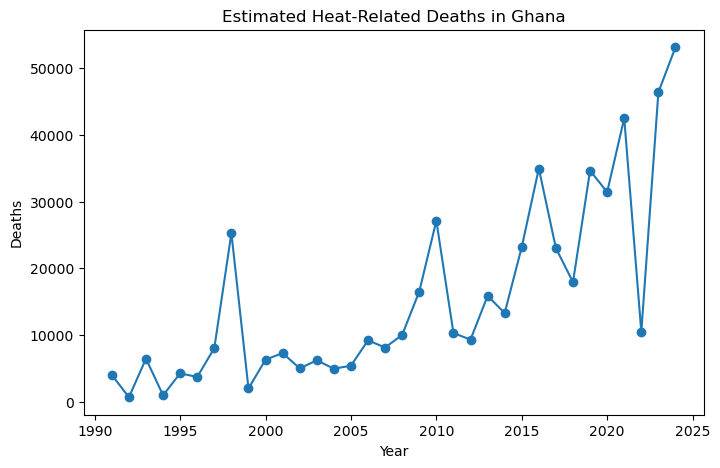

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

heat_deaths.plot(marker="o")

plt.title("Estimated Heat-Related Deaths in Ghana")
plt.ylabel("Deaths")
plt.xlabel("Year")

plt.show()

In [33]:
EHF

<xarray.DataArray 'EHF' (valid_time: 12419, latitude: 31, longitude: 21)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.3337822 , 0.26602364, 0.28180199, ..., 0.4123806 ,
         0.33031807, 0.27798119],
        [0.21111374, 0.16121483, 0.06012154, ..., 0.3679985 ,
         0.37374458, 0.34493599],
        [0.20429001, 0.16051559, 0.02122459, ..., 0.34544868,
         0.37375145, 0.35627632]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.33955956, 0.25909081, 0.28969917, ..., 0.37901268,
         0.35083199, 0.27196579],
        [0.53328514, 0.45888863, 0.4398735 , ..., 0.42160835,
         0.42139549, 0.36192284],
        [0.52207222, 0.49808006, 0.45372505, ..., 0.43294334,
         0.42519722, 0.37237206]]])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1991-01-01T11:30:00 ... 2024-12-3...
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
    dayofyear   (valid_time) int64 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366

In [35]:
delta_ehf = EHF.where(EHF > 0, 0)
delta_ehf

<xarray.DataArray 'EHF' (valid_time: 12419, latitude: 31, longitude: 21)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
...
        [0.3337822 , 0.26602364, 0.28180199, ..., 0.4123806 ,
         0.33031807, 0.27798119],
        [0.21111374, 0.16121483, 0.06012154, ..., 0.3679985 ,
         0.37374458, 0.34493599],
        [0.20429001, 0.16051559, 0.02122459, ..., 0.34544868,
         0.37375145, 0.35627632]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.33955956, 0.25909081, 0.28969917, ..., 0.37901268,
         0.35083199, 0.27196579],
        [0.53328514, 0.45888863, 0.4398735 , ..., 0.42160835,
         0.42139549, 0.36192284],
        [0.52207222, 0.49808006, 0.45372505, ..., 0.43294334,
         0.42519722, 0.37237206]]])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1991-01-01T11:30:00 ... 2024-12-3...
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
    dayofyear   (valid_time) int64 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366

In [37]:
beta = 0.005

RR = np.exp(beta * delta_ehf)
RR

<xarray.DataArray 'EHF' (valid_time: 12419, latitude: 31, longitude: 21)>
array([[[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
...
        [1.0016703 , 1.001331  , 1.00141   , ..., 1.00206403,
         1.00165295, 1.00139087],
        [1.00105613, 1.0008064 , 1.00030065, ..., 1.00184169,
         1.00187047, 1.00172617],
        [1.00102197, 1.0008029 , 1.00010613, ..., 1.00172874,
         1.0018705 , 1.00178297]],

       [[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.00169924, 1.00129629, 1.00144955, ..., 1.00189686,
         1.0017557 , 1.00136075],
        [1.00266998, 1.00229708, 1.00220179, ..., 1.00211027,
         1.0021092 , 1.00181125],
        [1.00261377, 1.0024935 , 1.0022712 , ..., 1.00216706,
         1.00212825, 1.00186359]]])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1991-01-01T11:30:00 ... 2024-12-3...
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
    dayofyear   (valid_time) int64 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366

In [38]:
RR_year = RR.resample(valid_time="1Y").mean()
RR_year

C:\Users\ampon\anaconda3\lib\site-packages\xarray\core\groupby.py:508: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index_grouper = pd.Grouper(


<xarray.DataArray 'EHF' (valid_time: 34, latitude: 31, longitude: 21)>
array([[[1.00002257, 1.00001591, 1.00002636, ..., 1.00007029,
         1.00004253, 1.00000836],
        [1.00000561, 1.00001431, 1.00002387, ..., 1.00004331,
         1.00002788, 1.00000673],
        [1.00000401, 1.00000485, 1.00001514, ..., 1.0000273 ,
         1.00002517, 1.00002405],
        ...,
        [1.0000269 , 1.00001538, 1.00001681, ..., 1.00009202,
         1.00008623, 1.00008932],
        [1.00005054, 1.00004391, 1.00004554, ..., 1.00011146,
         1.00011363, 1.00010619],
        [1.0000387 , 1.00003873, 1.0000459 , ..., 1.00013375,
         1.00012548, 1.00011654]],

       [[1.        , 1.        , 1.        , ..., 1.00003464,
         1.00005937, 1.00004866],
        [1.        , 1.        , 1.        , ..., 1.00000625,
         1.00001585, 1.0000012 ],
        [1.        , 1.        , 1.        , ..., 1.00000335,
         1.0000097 , 1.00002429],
...
        [1.0007897 , 1.00077376, 1.00079156, ..., 1.00082266,
         1.00081374, 1.00078938],
        [1.00082508, 1.00078692, 1.00079726, ..., 1.00079685,
         1.00077839, 1.00077605],
        [1.00078707, 1.00077276, 1.00077528, ..., 1.00075346,
         1.00072843, 1.0007255 ]],

       [[1.00149068, 1.00148664, 1.00116395, ..., 1.00112262,
         1.00104317, 1.00099081],
        [1.00145443, 1.00143532, 1.00111627, ..., 1.00094807,
         1.00087127, 1.00088272],
        [1.00143432, 1.00140233, 1.00147102, ..., 1.00091148,
         1.00086873, 1.00090812],
        ...,
        [1.00106238, 1.00099663, 1.00105827, ..., 1.00105969,
         1.00100933, 1.00096771],
        [1.00108101, 1.00101537, 1.00100881, ..., 1.00105936,
         1.00102165, 1.00100968],
        [1.00107879, 1.00106126, 1.00103582, ..., 1.00106593,
         1.00105728, 1.00105619]]])
Coordinates:
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

In [39]:
AF = (RR_year - 1) / RR_year
AF

<xarray.DataArray 'EHF' (valid_time: 34, latitude: 31, longitude: 21)>
array([[[2.25689438e-05, 1.59094004e-05, 2.63613918e-05, ...,
         7.02876268e-05, 4.25275446e-05, 8.36318026e-06],
        [5.61309881e-06, 1.43066183e-05, 2.38708834e-05, ...,
         4.33035685e-05, 2.78767477e-05, 6.73004491e-06],
        [4.01289405e-06, 4.84678058e-06, 1.51430185e-05, ...,
         2.73007653e-05, 2.51652055e-05, 2.40509176e-05],
        ...,
        [2.68969769e-05, 1.53783378e-05, 1.68103242e-05, ...,
         9.20138003e-05, 8.62244584e-05, 8.93153026e-05],
        [5.05396447e-05, 4.39070744e-05, 4.55413443e-05, ...,
         1.11451049e-04, 1.13615431e-04, 1.06181155e-04],
        [3.87026902e-05, 3.87316403e-05, 4.58967833e-05, ...,
         1.33729296e-04, 1.25460414e-04, 1.16530343e-04]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.46378233e-05, 5.93629923e-05, 4.86615557e-05],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         6.25278915e-06, 1.58532203e-05, 1.19592810e-06],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.35070729e-06, 9.70115101e-06, 2.42869121e-05],
...
        [7.89079522e-04, 7.73166485e-04, 7.90933574e-04, ...,
         8.21983435e-04, 8.13083168e-04, 7.88753198e-04],
        [8.24399943e-04, 7.86302740e-04, 7.96623539e-04, ...,
         7.96219330e-04, 7.77786736e-04, 7.75448393e-04],
        [7.86455894e-04, 7.72164065e-04, 7.74682336e-04, ...,
         7.52889331e-04, 7.27903745e-04, 7.24978212e-04]],

       [[1.48846542e-03, 1.48442820e-03, 1.16259350e-03, ...,
         1.12135779e-03, 1.04208012e-03, 9.89826442e-04],
        [1.45232127e-03, 1.43326603e-03, 1.11502580e-03, ...,
         9.47170436e-04, 8.70507471e-04, 8.81941891e-04],
        [1.43226656e-03, 1.40037060e-03, 1.46885915e-03, ...,
         9.10646586e-04, 8.67978957e-04, 9.07296299e-04],
        ...,
        [1.06125747e-03, 9.95641780e-04, 1.05714626e-03, ...,
         1.05856480e-03, 1.00831553e-03, 9.66772746e-04],
        [1.07984026e-03, 1.01433522e-03, 1.00779610e-03, ...,
         1.05824169e-03, 1.02061096e-03, 1.00866155e-03],
        [1.07762996e-03, 1.06013702e-03, 1.03474872e-03, ...,
         1.06479301e-03, 1.05615914e-03, 1.05507862e-03]]])
Coordinates:
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

In [53]:
heat_deaths = AF * 244911
heat_deaths

<xarray.DataArray 'EHF' (valid_time: 34, latitude: 31, longitude: 21)>
array([[[5.52738259e+00, 3.89638716e+00, 6.45619483e+00, ...,
         1.72142130e+01, 1.04154635e+01, 2.04823484e+00],
        [1.37470964e+00, 3.50384819e+00, 5.84624192e+00, ...,
         1.06055203e+01, 6.82732215e+00, 1.64826203e+00],
        [9.82801895e-01, 1.18702988e+00, 3.70869180e+00, ...,
         6.68625774e+00, 6.16323564e+00, 5.89033428e+00],
        ...,
        [6.58736552e+00, 3.76632408e+00, 4.11703332e+00, ...,
         2.25351918e+01, 2.11173183e+01, 2.18743001e+01],
        [1.23777149e+01, 1.07533255e+01, 1.11535762e+01, ...,
         2.72955879e+01, 2.78256687e+01, 2.60049329e+01],
        [9.47871455e+00, 9.48580475e+00, 1.12406271e+01, ...,
         3.27517755e+01, 3.07266356e+01, 2.85395629e+01]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         8.48318395e+00, 1.45386498e+01, 1.19177503e+01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         1.53137684e+00, 3.88262803e+00, 2.92895947e-01],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         8.20625074e-01, 2.37591859e+00, 5.94813193e+00],
...
        [1.93254255e+02, 1.89356977e+02, 1.93708333e+02, ...,
         2.01312785e+02, 1.99133012e+02, 1.93174334e+02],
        [2.01904614e+02, 1.92574190e+02, 1.95101868e+02, ...,
         1.95002872e+02, 1.90488527e+02, 1.89915841e+02],
        [1.92611700e+02, 1.89111473e+02, 1.89728225e+02, ...,
         1.84390879e+02, 1.78271634e+02, 1.77555139e+02]],

       [[3.64541556e+02, 3.63552795e+02, 2.84731936e+02, ...,
         2.74632857e+02, 2.55216885e+02, 2.42419384e+02],
        [3.55689454e+02, 3.51022616e+02, 2.73082083e+02, ...,
         2.31972459e+02, 2.13196855e+02, 2.15997271e+02],
        [3.50777836e+02, 3.42966165e+02, 3.59739763e+02, ...,
         2.23027366e+02, 2.12577594e+02, 2.22206844e+02],
        ...,
        [2.59913628e+02, 2.43843624e+02, 2.58906748e+02, ...,
         2.59254165e+02, 2.46947566e+02, 2.36773280e+02],
        [2.64464758e+02, 2.48421854e+02, 2.46820351e+02, ...,
         2.59175031e+02, 2.49958850e+02, 2.47032308e+02],
        [2.63923431e+02, 2.59639217e+02, 2.53421343e+02, ...,
         2.60779520e+02, 2.58664991e+02, 2.58400360e+02]]])
Coordinates:
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

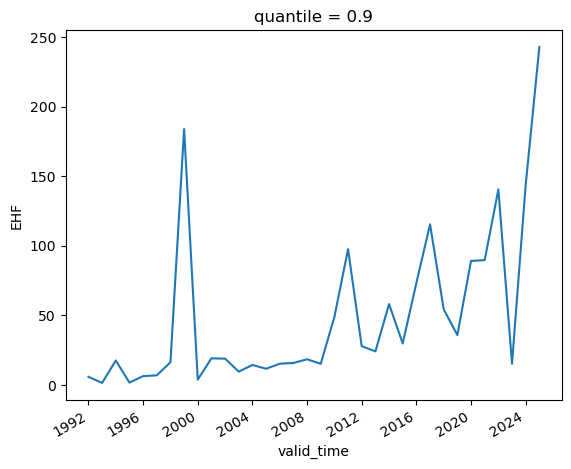

In [54]:
AF_country = AF.mean(dim=["latitude","longitude"])

heat_deaths_country = AF_country * baseline_deaths
heat_deaths_country.plot()

In [43]:
beta = 0.005
RR = xr.where(EHF > 0, np.exp(beta * EHF), 1)
RR

<xarray.DataArray 'EHF' (valid_time: 12419, latitude: 31, longitude: 21)>
array([[[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ]],

       [[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
...
        [1.0016703 , 1.001331  , 1.00141   , ..., 1.00206403,
         1.00165295, 1.00139087],
        [1.00105613, 1.0008064 , 1.00030065, ..., 1.00184169,
         1.00187047, 1.00172617],
        [1.00102197, 1.0008029 , 1.00010613, ..., 1.00172874,
         1.0018705 , 1.00178297]],

       [[1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        [1.        , 1.        , 1.        , ..., 1.        ,
         1.        , 1.        ],
        ...,
        [1.00169924, 1.00129629, 1.00144955, ..., 1.00189686,
         1.0017557 , 1.00136075],
        [1.00266998, 1.00229708, 1.00220179, ..., 1.00211027,
         1.0021092 , 1.00181125],
        [1.00261377, 1.0024935 , 1.0022712 , ..., 1.00216706,
         1.00212825, 1.00186359]]])
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 1991-01-01T11:30:00 ... 2024-12-3...
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
    dayofyear   (valid_time) int64 1 2 3 4 5 6 7 ... 360 361 362 363 364 365 366

In [45]:
RR_year = RR.resample(valid_time="YE").mean()
RR_year

<xarray.DataArray 'EHF' (valid_time: 34, latitude: 31, longitude: 21)>
array([[[1.00002257, 1.00001591, 1.00002636, ..., 1.00007029,
         1.00004253, 1.00000836],
        [1.00000561, 1.00001431, 1.00002387, ..., 1.00004331,
         1.00002788, 1.00000673],
        [1.00000401, 1.00000485, 1.00001514, ..., 1.0000273 ,
         1.00002517, 1.00002405],
        ...,
        [1.0000269 , 1.00001538, 1.00001681, ..., 1.00009202,
         1.00008623, 1.00008932],
        [1.00005054, 1.00004391, 1.00004554, ..., 1.00011146,
         1.00011363, 1.00010619],
        [1.0000387 , 1.00003873, 1.0000459 , ..., 1.00013375,
         1.00012548, 1.00011654]],

       [[1.        , 1.        , 1.        , ..., 1.00003464,
         1.00005937, 1.00004866],
        [1.        , 1.        , 1.        , ..., 1.00000625,
         1.00001585, 1.0000012 ],
        [1.        , 1.        , 1.        , ..., 1.00000335,
         1.0000097 , 1.00002429],
...
        [1.0007897 , 1.00077376, 1.00079156, ..., 1.00082266,
         1.00081374, 1.00078938],
        [1.00082508, 1.00078692, 1.00079726, ..., 1.00079685,
         1.00077839, 1.00077605],
        [1.00078707, 1.00077276, 1.00077528, ..., 1.00075346,
         1.00072843, 1.0007255 ]],

       [[1.00149068, 1.00148664, 1.00116395, ..., 1.00112262,
         1.00104317, 1.00099081],
        [1.00145443, 1.00143532, 1.00111627, ..., 1.00094807,
         1.00087127, 1.00088272],
        [1.00143432, 1.00140233, 1.00147102, ..., 1.00091148,
         1.00086873, 1.00090812],
        ...,
        [1.00106238, 1.00099663, 1.00105827, ..., 1.00105969,
         1.00100933, 1.00096771],
        [1.00108101, 1.00101537, 1.00100881, ..., 1.00105936,
         1.00102165, 1.00100968],
        [1.00107879, 1.00106126, 1.00103582, ..., 1.00106593,
         1.00105728, 1.00105619]]])
Coordinates:
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

In [46]:
AF = (RR_year - 1) / RR_year
AF

<xarray.DataArray 'EHF' (valid_time: 34, latitude: 31, longitude: 21)>
array([[[2.25689438e-05, 1.59094004e-05, 2.63613918e-05, ...,
         7.02876268e-05, 4.25275446e-05, 8.36318026e-06],
        [5.61309881e-06, 1.43066183e-05, 2.38708834e-05, ...,
         4.33035685e-05, 2.78767477e-05, 6.73004491e-06],
        [4.01289405e-06, 4.84678058e-06, 1.51430185e-05, ...,
         2.73007653e-05, 2.51652055e-05, 2.40509176e-05],
        ...,
        [2.68969769e-05, 1.53783378e-05, 1.68103242e-05, ...,
         9.20138003e-05, 8.62244584e-05, 8.93153026e-05],
        [5.05396447e-05, 4.39070744e-05, 4.55413443e-05, ...,
         1.11451049e-04, 1.13615431e-04, 1.06181155e-04],
        [3.87026902e-05, 3.87316403e-05, 4.58967833e-05, ...,
         1.33729296e-04, 1.25460414e-04, 1.16530343e-04]],

       [[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.46378233e-05, 5.93629923e-05, 4.86615557e-05],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         6.25278915e-06, 1.58532203e-05, 1.19592810e-06],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.35070729e-06, 9.70115101e-06, 2.42869121e-05],
...
        [7.89079522e-04, 7.73166485e-04, 7.90933574e-04, ...,
         8.21983435e-04, 8.13083168e-04, 7.88753198e-04],
        [8.24399943e-04, 7.86302740e-04, 7.96623539e-04, ...,
         7.96219330e-04, 7.77786736e-04, 7.75448393e-04],
        [7.86455894e-04, 7.72164065e-04, 7.74682336e-04, ...,
         7.52889331e-04, 7.27903745e-04, 7.24978212e-04]],

       [[1.48846542e-03, 1.48442820e-03, 1.16259350e-03, ...,
         1.12135779e-03, 1.04208012e-03, 9.89826442e-04],
        [1.45232127e-03, 1.43326603e-03, 1.11502580e-03, ...,
         9.47170436e-04, 8.70507471e-04, 8.81941891e-04],
        [1.43226656e-03, 1.40037060e-03, 1.46885915e-03, ...,
         9.10646586e-04, 8.67978957e-04, 9.07296299e-04],
        ...,
        [1.06125747e-03, 9.95641780e-04, 1.05714626e-03, ...,
         1.05856480e-03, 1.00831553e-03, 9.66772746e-04],
        [1.07984026e-03, 1.01433522e-03, 1.00779610e-03, ...,
         1.05824169e-03, 1.02061096e-03, 1.00866155e-03],
        [1.07762996e-03, 1.06013702e-03, 1.03474872e-03, ...,
         1.06479301e-03, 1.05615914e-03, 1.05507862e-03]]])
Coordinates:
  * longitude   (longitude) float64 -3.5 -3.25 -3.0 -2.75 ... 0.75 1.0 1.25 1.5
  * latitude    (latitude) float64 12.0 11.75 11.5 11.25 ... 5.25 5.0 4.75 4.5
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

In [47]:
AF_country = AF.mean(dim=["latitude","longitude"])
AF_country

<xarray.DataArray 'EHF' (valid_time: 34)>
array([2.37206135e-05, 5.80218254e-06, 7.15268629e-05, 6.72407863e-06,
       2.58008083e-05, 2.79945309e-05, 6.64994273e-05, 7.50455894e-04,
       1.53474436e-05, 7.79052982e-05, 7.69213555e-05, 3.88475997e-05,
       5.85147129e-05, 4.72585671e-05, 6.21308078e-05, 6.42199083e-05,
       7.51071399e-05, 6.18491807e-05, 1.99524681e-04, 3.98113600e-04,
       1.13556995e-04, 9.83341545e-05, 2.36965806e-04, 1.21546863e-04,
       2.98739013e-04, 4.70959188e-04, 2.21490542e-04, 1.46081523e-04,
       3.63536305e-04, 3.66006473e-04, 5.73463934e-04, 6.19940988e-05,
       5.86081397e-04, 9.91323529e-04])
Coordinates:
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

In [49]:
baseline_deaths = 244991
heat_deaths = AF_country * baseline_deaths
heat_deaths

<xarray.DataArray 'EHF' (valid_time: 34)>
array([  5.81133682,   1.4214825 ,  17.52343768,   1.64733875,
         6.32096582,   6.85840812,  16.29176119, 183.85493985,
         3.75998556,  19.0860969 ,  18.8450398 ,   9.51731231,
        14.33557802,  11.57792362,  15.22148874,  15.73329956,
        18.40057331,  15.15249264,  48.88175123,  97.53424896,
        27.82044178,  24.09098284,  58.05448989,  29.77788739,
        73.18836946, 115.38076234,  54.26318945,  35.7886585 ,
        89.06312301,  89.66829182, 140.49350264,  15.18799627,
       143.5846676 , 242.86534263])
Coordinates:
    quantile    float64 0.9
  * valid_time  (valid_time) datetime64[ns] 1991-12-31 1992-12-31 ... 2024-12-31

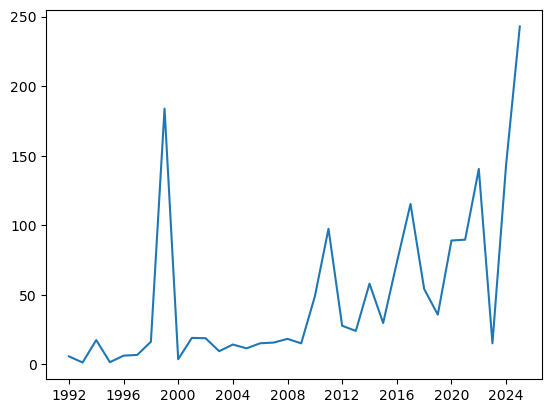

In [50]:
plt.plot(heat_deaths.valid_time,heat_deaths.values)